# Test Dataset Creation: Classification Evaluation Set

Creates a test dataset of 50 prompts for evaluating a cosine similarity-based centroid classifier:
- **30 clear** single-category samples (10 per category) from different sources than training
- **20 ambiguous** boundary samples blending two categories (manually written)

Output: `test_dataset.csv`

In [8]:
# Cell 1: Setup
!pip install -q datasets pandas matplotlib

import re
import json
import random
import urllib.request
import tarfile
import io
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TARGET_MIN = 25
TARGET_MAX = 45

def clean_text(text):
    """General cleaning: strip, collapse whitespace."""
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def word_count(text):
    return len(text.split())

print("Setup complete.")

Setup complete.


In [9]:
# Cell 2: Load Clear Math Samples
# hendrycks/competition_math uses a legacy script loader, so we use
# nlile/hendrycks-MATH-benchmark which has the same data in parquet format.
print("Loading MATH benchmark...")
math_ds = load_dataset("nlile/hendrycks-MATH-benchmark", split="test")
math_source = "competition_math"

print(f"Raw count: {len(math_ds)}")
print(f"Columns: {math_ds.column_names}")

# Determine the problem field name
p_field = "problem" if "problem" in math_ds.column_names else math_ds.column_names[0]

math_clear = []
for row in math_ds:
    prompt = clean_text(row[p_field])
    wc = word_count(prompt)
    if prompt and TARGET_MIN <= wc <= TARGET_MAX:
        math_clear.append({
            "prompt": prompt,
            "conversation_type": "math",
            "source": math_source,
            "word_count": wc,
            "ambiguous": False,
            "blend_type": "none",
            "expected_primary": "math",
            "expected_secondary": "none"
        })

print(f"After filtering [{TARGET_MIN}-{TARGET_MAX}]: {len(math_clear)} available")

df_math_clear = pd.DataFrame(math_clear).sample(n=10, random_state=SEED).reset_index(drop=True)
print(f"Sampled {len(df_math_clear)} math prompts:")
for i, row in df_math_clear.iterrows():
    print(f"  [{i+1}] ({row['word_count']}w) {row['prompt'][:120]}")

Loading MATH benchmark...
Raw count: 500
Columns: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']
After filtering [25-45]: 169 available
Sampled 10 math prompts:
  [1] (35w) Let $P(x)$ be a quadratic polynomial with real coefficients satisfying $x^2 - 2x + 2 \le P(x) \le 2x^2 - 4x + 3$ for all
  [2] (29w) Two fair, 6-sided dice are thrown. What is the probability that the product of the two numbers is a multiple of 5? Expre
  [3] (35w) An equilateral triangle is inscribed in the parabola $x^2 = 8y,$ such that one of the vertices of the triangle coincides
  [4] (42w) The operation $\&$ is defined for positive integers $a$ and $b$ as $a \& b = \displaystyle\frac{\sqrt{a b + a}}{\sqrt{a 
  [5] (29w) Three pencils and a jumbo eraser cost $\$1.24$. Five pencils and a jumbo eraser cost $\$1.82$. No prices include tax. In
  [6] (36w) A steel sphere with a 3-inch radius is made by removing metal from the corners of a cube that has the shortest possible 
  [7] (36w) The set o

In [10]:
# Cell 3: Load Clear Riddle Samples (BrainTeaser + fallback)
print("Loading BrainTeaser...")
riddle_clear = []
bt_loaded = False

try:
    brain_teaser = load_dataset("ChenLiu1996/Brainteaser", split="train")
    bt_loaded = True
except Exception:
    try:
        brain_teaser = load_dataset("ChenLiu1996/Brainteaser", split="test")
        bt_loaded = True
    except Exception as e:
        print(f"BrainTeaser failed: {e}")

if bt_loaded:
    print(f"Raw count: {len(brain_teaser)}")
    print(f"Columns: {brain_teaser.column_names}")
    print(f"Sample: {brain_teaser[0]}")

    q_field = "question" if "question" in brain_teaser.column_names else brain_teaser.column_names[0]

    for row in brain_teaser:
        prompt = clean_text(row[q_field])
        wc = word_count(prompt)
        if prompt and TARGET_MIN <= wc <= TARGET_MAX:
            riddle_clear.append({
                "prompt": prompt,
                "conversation_type": "riddle",
                "source": "brain_teaser",
                "word_count": wc,
                "ambiguous": False,
                "blend_type": "none",
                "expected_primary": "riddle",
                "expected_secondary": "none"
            })
    print(f"After filtering [{TARGET_MIN}-{TARGET_MAX}]: {len(riddle_clear)} available")

# Fallback riddles in case BrainTeaser yields fewer than 10
fallback_riddles = [
    "I have cities but no houses live in them. I have mountains but no trees grow on them. I have water but no fish swim in it. I have roads but no cars drive on them. What am I?",
    "A man is looking at a photograph. His friend asks who it is. He replies he has no brothers or sisters but that persons father is his fathers son. Who is in the photograph?",
    "I can be cracked and I can be made. I can be told and I can be played. Sometimes I am funny and sometimes I fall flat. People share me at parties. What am I?",
    "The more you take from me the bigger I become. I am nothing when you first see me but I grow with every step you take away from where you started. What am I?",
    "I speak without a mouth and hear without ears. I have no body but I come alive with the wind. I live in mountains and valleys traveling far without ever leaving my place. What am I?",
    "What has keys but no locks, space but no room, and you can enter but cannot go inside? You use it every day but most people never think about what it really is.",
    "I have a head and a tail but no body. I am not alive but people flip me to make decisions. I am worth very little but sometimes I can change everything. What am I?",
    "What goes up but never comes down? It increases every year on a special day and people celebrate when it does. You cannot see it or touch it but everyone keeps track of it.",
    "I am not alive but I grow. I have no lungs but I need air. I have no mouth but water kills me. You can find me in a fireplace or burning on a candle. What am I?",
    "I follow you everywhere you go during the day but disappear at night or when the lights go out. I copy everything you do but you can never catch me. What am I?",
    "I have hands but cannot clap. I have a face but cannot smile. I tell you something important every time you look at me but I never speak a single word. What am I?",
    "I am always in front of you but I can never be seen. People chase me their whole lives but nobody has ever caught me. Some fear me while others look forward to me. What am I?",
]

if len(riddle_clear) < 10:
    needed = 10 - len(riddle_clear)
    print()
    print(f"Only {len(riddle_clear)} from BrainTeaser. Adding fallback riddles (need {needed} more)...")
    for riddle in fallback_riddles:
        if len(riddle_clear) >= 10:
            break
        cleaned = clean_text(riddle)
        wc = word_count(cleaned)
        if TARGET_MIN <= wc <= TARGET_MAX:
            riddle_clear.append({
                "prompt": cleaned,
                "conversation_type": "riddle",
                "source": "manual",
                "word_count": wc,
                "ambiguous": False,
                "blend_type": "none",
                "expected_primary": "riddle",
                "expected_secondary": "none"
            })
    print(f"After adding fallbacks: {len(riddle_clear)} available")

df_riddle_clear = pd.DataFrame(riddle_clear)
if len(df_riddle_clear) > 10:
    df_riddle_clear = df_riddle_clear.sample(n=10, random_state=SEED).reset_index(drop=True)
else:
    df_riddle_clear = df_riddle_clear.reset_index(drop=True)

print()
print(f"Final {len(df_riddle_clear)} riddle prompts:")
for i, row in df_riddle_clear.iterrows():
    print(f"  [{i+1}] ({row['word_count']}w) [{row['source']}] {row['prompt'][:120]}")


Loading BrainTeaser...


README.md: 0.00B [00:00, ?B/s]

BrainTeaser failed: Dataset 'ChenLiu1996/Brainteaser' is a gated dataset on the Hub. You must be authenticated to access it.

Only 0 from BrainTeaser. Adding fallback riddles (need 10 more)...
After adding fallbacks: 10 available

Final 10 riddle prompts:
  [1] (39w) [manual] I have cities but no houses live in them. I have mountains but no trees grow on them. I have water but no fish swim in i
  [2] (34w) [manual] A man is looking at a photograph. His friend asks who it is. He replies he has no brothers or sisters but that persons f
  [3] (35w) [manual] I can be cracked and I can be made. I can be told and I can be played. Sometimes I am funny and sometimes I fall flat. P
  [4] (34w) [manual] The more you take from me the bigger I become. I am nothing when you first see me but I grow with every step you take aw
  [5] (36w) [manual] I speak without a mouth and hear without ears. I have no body but I come alive with the wind. I live in mountains and va
  [6] (33w) [manual] What has keys

In [11]:
# Cell 4: Load Clear Emotional Samples (empathetic_dialogues TEST split)
# Same direct-download approach as training, but using test.csv

EMP_URL = "https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz"

print("Loading Empathetic Dialogues TEST split (downloading from source)...")
response = urllib.request.urlopen(EMP_URL)
archive = tarfile.open(fileobj=io.BytesIO(response.read()), mode="r:gz")

# Extract test.csv (not train.csv)
test_member = [m for m in archive.getmembers() if "test.csv" in m.name][0]
f = archive.extractfile(test_member)
reader = csv.DictReader(io.TextIOWrapper(f, encoding="utf-8"))
rows = list(reader)
print(f"Raw row count: {len(rows)}")
print(f"Columns: {list(rows[0].keys())}")

def decode_empathetic_tokens(text):
    replacements = {
        "_comma_": ",", "_apostrophe_": "'", "_exclamation_": "!",
        "_question_": "?", "_period_": ".", "_colon_": ":",
        "_semicolon_": ";", "_dash_": "-", "_at_": "@",
        "_hash_": "#", "_amp_": "&", "_percent_": "%",
        "_dollar_": "$", "_star_": "*", "_caret_": "^",
        "_tilde_": "~", "_pipe_": "|", "_backslash_": "\\",
        "_slash_": "/", "_leftparen_": "(", "_rightparen_": ")",
        "_leftbracket_": "[", "_rightbracket_": "]",
        "_leftbrace_": "{", "_rightbrace_": "}",
        "_lessthan_": "<", "_greaterthan_": ">",
        "_equal_": "=", "_plus_": "+",
    }
    for token, char in replacements.items():
        text = text.replace(token, char)
    return text

seen_conv_ids = set()
emotional_clear = []

for row in rows:
    conv_id = row["conv_id"]
    utterance_idx = int(row["utterance_idx"])

    if utterance_idx == 1 and conv_id not in seen_conv_ids:
        seen_conv_ids.add(conv_id)
        text = decode_empathetic_tokens(row["utterance"])
        prompt = clean_text(text)
        wc = word_count(prompt)
        if prompt and TARGET_MIN <= wc <= TARGET_MAX:
            emotional_clear.append({
                "prompt": prompt,
                "conversation_type": "emotional",
                "source": "empathetic_dialogues_test",
                "word_count": wc,
                "ambiguous": False,
                "blend_type": "none",
                "expected_primary": "emotional",
                "expected_secondary": "none"
            })

print(f"After filtering [{TARGET_MIN}-{TARGET_MAX}]: {len(emotional_clear)} available")

df_emotional_clear = pd.DataFrame(emotional_clear).sample(n=10, random_state=SEED).reset_index(drop=True)
print(f"\nSampled {len(df_emotional_clear)} emotional prompts:")
for i, row in df_emotional_clear.iterrows():
    print(f"  [{i+1}] ({row['word_count']}w) {row['prompt'][:120]}")

Loading Empathetic Dialogues TEST split (downloading from source)...
Raw row count: 10943
Columns: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags']
After filtering [25-45]: 471 available

Sampled 10 emotional prompts:
  [1] (35w) I went on this ride at the beach called the Slingshot.. It shoots you super high up in the air.. It was so teriffying, I
  [2] (28w) I bought a chocolate bar for my wife at the store, and I was going to give it to her, but I ended up eating it...I feel 
  [3] (29w) My friend is a surgeon and we were discussing salary. He easily makes 200,000 a year and he is only 32. It's crazy and I
  [4] (34w) I had a secret and went to my mother to confide in her, as well as get off my chest. I know she would never betray my se
  [5] (32w) Bought a new car a few months back. Couple nights ago we had a big storm roll through. I thought for sure it was going t
  [6] (27w) We just got back from the beach two weeks ago. It was su

In [12]:
# Cell 5: Create Ambiguous / Boundary Samples (20 total)
print("Creating ambiguous boundary samples...")
print("All prompts are manually written to genuinely straddle two categories.\n")

ambiguous_prompts = [
    # â”€â”€ Math + Emotional (7) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    {
        "prompt": "My parents are getting divorced and they need to split their savings of $12,000 between three children. My older sister gets twice what I get because she is in college. How much do I receive?",
        "blend_type": "math_emotional",
        "expected_primary": "math",
        "expected_secondary": "emotional"
    },
    {
        "prompt": "I just lost my job and I have $3,400 left in savings. My rent is $850 per month and groceries cost about $200 per month. How many months can I survive before the money runs out completely?",
        "blend_type": "math_emotional",
        "expected_primary": "math",
        "expected_secondary": "emotional"
    },
    {
        "prompt": "My grandmother passed away and left us an inheritance. After paying $4,500 in taxes the remaining $18,000 needs to be divided among four grandchildren. If split equally how much does each person get?",
        "blend_type": "math_emotional",
        "expected_primary": "math",
        "expected_secondary": "emotional"
    },
    {
        "prompt": "After my dog died I spent $2,300 on emergency vet bills that went to waste. Now I owe $800 on my credit card and only make $1,500 per month. How long until I can pay off this heartbreaking debt?",
        "blend_type": "math_emotional",
        "expected_primary": "math",
        "expected_secondary": "emotional"
    },
    {
        "prompt": "My best friend borrowed $450 from me six months ago and keeps avoiding me. She has paid back only $120 so far. I feel betrayed but I need the money. How much does she still owe me?",
        "blend_type": "math_emotional",
        "expected_primary": "emotional",
        "expected_secondary": "math"
    },
    {
        "prompt": "I am terrified of failing my exam tomorrow. There are 45 questions worth 2 points each and 5 bonus questions worth 3 points each. If I need 70 points to pass how many regular questions must I get right?",
        "blend_type": "math_emotional",
        "expected_primary": "math",
        "expected_secondary": "emotional"
    },
    {
        "prompt": "My son was just diagnosed with a condition requiring medication that costs $340 per month. Our insurance covers only 60 percent. We already spend $200 monthly on his other prescriptions. What will our new total monthly cost be?",
        "blend_type": "math_emotional",
        "expected_primary": "math",
        "expected_secondary": "emotional"
    },

    # â”€â”€ Riddle + Math (7) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    {
        "prompt": "Two fathers and two sons go fishing together. They each catch exactly one fish yet only three fish are caught in total. No fish were thrown back and none were shared. How is this possible?",
        "blend_type": "riddle_math",
        "expected_primary": "riddle",
        "expected_secondary": "math"
    },
    {
        "prompt": "A farmer has seventeen sheep. All but nine die in a terrible storm. The farmer counts the survivors three times and gets a different answer each time. How many sheep does he actually have left alive?",
        "blend_type": "riddle_math",
        "expected_primary": "riddle",
        "expected_secondary": "math"
    },
    {
        "prompt": "I am a three digit number. My tens digit is five more than my ones digit. My hundreds digit is eight less than my tens digit. Every digit is different and they all add up to fifteen. What number am I?",
        "blend_type": "riddle_math",
        "expected_primary": "riddle",
        "expected_secondary": "math"
    },
    {
        "prompt": "A clock strikes six in five seconds. How long does it take to strike twelve? Think carefully about the intervals between each strike not just the number of strikes themselves. The answer is not ten seconds.",
        "blend_type": "riddle_math",
        "expected_primary": "riddle",
        "expected_secondary": "math"
    },
    {
        "prompt": "If you have a bowl with six apples and you take away four how many apples do you have? Most people answer two but the real answer requires thinking about what you are actually holding in your hands.",
        "blend_type": "riddle_math",
        "expected_primary": "riddle",
        "expected_secondary": "math"
    },
    {
        "prompt": "Three people check into a hotel room that costs thirty dollars. They each pay ten dollars. The manager realizes it should be twenty-five dollars and gives five dollars back. Where did the missing dollar go?",
        "blend_type": "riddle_math",
        "expected_primary": "riddle",
        "expected_secondary": "math"
    },
    {
        "prompt": "A snail is at the bottom of a thirty foot well. Each day it climbs three feet but slides back two feet at night. How many days does it take to escape? The obvious calculation gives the wrong answer.",
        "blend_type": "riddle_math",
        "expected_primary": "math",
        "expected_secondary": "riddle"
    },

    # â”€â”€ Emotional + Riddle (6) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    {
        "prompt": "My best friend has been acting strange for weeks. She says she is fine but her eyes tell a different story. She speaks to me every day but says nothing at all. What is happening to our friendship?",
        "blend_type": "emotional_riddle",
        "expected_primary": "emotional",
        "expected_secondary": "riddle"
    },
    {
        "prompt": "My coworker keeps leaving anonymous notes on my desk saying someone is spreading lies about me. But the handwriting looks familiar and nobody else knows anything about these rumors. Who should I trust in this situation?",
        "blend_type": "emotional_riddle",
        "expected_primary": "emotional",
        "expected_secondary": "riddle"
    },
    {
        "prompt": "Every morning my partner tells me they love me but every evening they come home smiling at messages from someone I have never met. They say it is just a work friend. Should I be worried about this?",
        "blend_type": "emotional_riddle",
        "expected_primary": "emotional",
        "expected_secondary": "riddle"
    },
    {
        "prompt": "I found a letter in my late father's belongings addressed to someone I have never heard of. It mentions a secret he kept for decades. I want to know the truth but I am afraid of what I might discover.",
        "blend_type": "emotional_riddle",
        "expected_primary": "emotional",
        "expected_secondary": "riddle"
    },
    {
        "prompt": "My neighbor smiles and waves at me every single day but last week I overheard her telling someone on the phone that she cannot stand living next to me. Why would someone pretend to be friendly while secretly resenting you?",
        "blend_type": "emotional_riddle",
        "expected_primary": "emotional",
        "expected_secondary": "riddle"
    },
    {
        "prompt": "My teenage daughter used to tell me everything but now she locks her door and whispers on the phone late at night. She seems happy but her grades are dropping fast. What is really going on with her?",
        "blend_type": "emotional_riddle",
        "expected_primary": "emotional",
        "expected_secondary": "riddle"
    },
]

# Build dataframe and validate word counts
ambig_rows = []
for item in ambiguous_prompts:
    prompt = clean_text(item["prompt"])
    wc = word_count(prompt)
    ambig_rows.append({
        "prompt": prompt,
        "conversation_type": "ambiguous",
        "source": "manual",
        "word_count": wc,
        "ambiguous": True,
        "blend_type": item["blend_type"],
        "expected_primary": item["expected_primary"],
        "expected_secondary": item["expected_secondary"]
    })

df_ambiguous = pd.DataFrame(ambig_rows)

# Validate word counts
out_of_range = df_ambiguous[(df_ambiguous["word_count"] < TARGET_MIN) | (df_ambiguous["word_count"] > TARGET_MAX)]
if len(out_of_range) > 0:
    print(f"WARNING: {len(out_of_range)} ambiguous prompts outside [{TARGET_MIN}-{TARGET_MAX}] word range:")
    for _, row in out_of_range.iterrows():
        print(f"  ({row['word_count']}w) {row['prompt'][:80]}...")
else:
    print(f"All {len(df_ambiguous)} ambiguous prompts are within [{TARGET_MIN}-{TARGET_MAX}] word range.")

print(f"\nCounts by blend_type:")
print(df_ambiguous["blend_type"].value_counts())

print(f"\n--- MATH + EMOTIONAL ---")
for _, r in df_ambiguous[df_ambiguous["blend_type"] == "math_emotional"].iterrows():
    print(f"  ({r['word_count']}w) [{r['expected_primary']}/{r['expected_secondary']}] {r['prompt'][:100]}...")

print(f"\n--- RIDDLE + MATH ---")
for _, r in df_ambiguous[df_ambiguous["blend_type"] == "riddle_math"].iterrows():
    print(f"  ({r['word_count']}w) [{r['expected_primary']}/{r['expected_secondary']}] {r['prompt'][:100]}...")

print(f"\n--- EMOTIONAL + RIDDLE ---")
for _, r in df_ambiguous[df_ambiguous["blend_type"] == "emotional_riddle"].iterrows():
    print(f"  ({r['word_count']}w) [{r['expected_primary']}/{r['expected_secondary']}] {r['prompt'][:100]}...")

Creating ambiguous boundary samples...
All prompts are manually written to genuinely straddle two categories.

All 20 ambiguous prompts are within [25-45] word range.

Counts by blend_type:
blend_type
math_emotional      7
riddle_math         7
emotional_riddle    6
Name: count, dtype: int64

--- MATH + EMOTIONAL ---
  (35w) [math/emotional] My parents are getting divorced and they need to split their savings of $12,000 between three childr...
  (37w) [math/emotional] I just lost my job and I have $3,400 left in savings. My rent is $850 per month and groceries cost a...
  (33w) [math/emotional] My grandmother passed away and left us an inheritance. After paying $4,500 in taxes the remaining $1...
  (39w) [math/emotional] After my dog died I spent $2,300 on emergency vet bills that went to waste. Now I owe $800 on my cre...
  (37w) [emotional/math] My best friend borrowed $450 from me six months ago and keeps avoiding me. She has paid back only $1...
  (39w) [math/emotional] I am terrif

In [13]:
# Cell 6: Combine, Validate, Save
print("Combining all samples...")

df_all = pd.concat([df_math_clear, df_riddle_clear, df_emotional_clear, df_ambiguous], ignore_index=True)

# Generate id column
ids = []
counters = {}
for _, row in df_all.iterrows():
    cat = row["conversation_type"]
    counters[cat] = counters.get(cat, 0) + 1
    ids.append(f"test_{cat}_{counters[cat]:03d}")

df_all["id"] = ids

# Reorder columns
df_all = df_all[["id", "conversation_type", "source", "prompt", "word_count",
                  "ambiguous", "blend_type", "expected_primary", "expected_secondary"]]

# Validation
print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

assert len(df_all) == 50, f"Expected 50 rows, got {len(df_all)}"
print("[PASS] Exactly 50 rows")

n_clear = len(df_all[df_all["ambiguous"] == False])
n_ambig = len(df_all[df_all["ambiguous"] == True])
assert n_clear == 30, f"Expected 30 clear, got {n_clear}"
assert n_ambig == 20, f"Expected 20 ambiguous, got {n_ambig}"
print(f"[PASS] 30 clear + 20 ambiguous")

wc_ok = ((df_all["word_count"] >= TARGET_MIN) & (df_all["word_count"] <= TARGET_MAX)).all()
if not wc_ok:
    oob = df_all[(df_all["word_count"] < TARGET_MIN) | (df_all["word_count"] > TARGET_MAX)]
    print(f"[WARN] {len(oob)} prompts outside [{TARGET_MIN}-{TARGET_MAX}] word range")
    print(oob[["id", "word_count", "prompt"]].to_string())
else:
    print(f"[PASS] All word counts in [{TARGET_MIN}-{TARGET_MAX}]")

assert df_all.isnull().sum().sum() == 0, "Found null values!"
print("[PASS] No null values")

# Save
output_path = "test_dataset.csv"
df_all.to_csv(output_path, index=False)
print(f"\nSaved to {output_path}")
print(f"Shape: {df_all.shape}")

print(f"\nAll rows:")
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 60)
df_all

Combining all samples...

VALIDATION
[PASS] Exactly 50 rows
[PASS] 30 clear + 20 ambiguous
[PASS] All word counts in [25-45]
[PASS] No null values

Saved to test_dataset.csv
Shape: (50, 9)

All rows:


,id,conversation_type,source,prompt,word_count,ambiguous,blend_type,expected_primary,expected_secondary
0,test_math_001,math,competition_math,Let $P(x)$ be a quadratic polynomial with real coefficients satisfying $x^2 ...,35,False,none,math,none
1,test_math_002,math,competition_math,"Two fair, 6-sided dice are thrown. What is the probability that the product ...",29,False,none,math,none
2,test_math_003,math,competition_math,"An equilateral triangle is inscribed in the parabola $x^2 = 8y,$ such that o...",35,False,none,math,none
3,test_math_004,math,competition_math,The operation $\&$ is defined for positive integers $a$ and $b$ as $a \& b =...,42,False,none,math,none
4,test_math_005,math,competition_math,Three pencils and a jumbo eraser cost $\$1.24$. Five pencils and a jumbo era...,29,False,none,math,none
5,test_math_006,math,competition_math,A steel sphere with a 3-inch radius is made by removing metal from the corne...,36,False,none,math,none
6,test_math_007,math,competition_math,The set of vectors $\mathbf{v}$ such that \[\operatorname{proj}_{\begin{pmat...,36,False,none,math,none
7,test_math_008,math,competition_math,How many zeroes are at the end of $42!$ (42 factorial)? (Reminder: The numbe...,31,False,none,math,none
8,test_math_009,math,competition_math,Let $P(x)$ be a monic polynomial of degree 3. Suppose that $P(x)$ has remain...,45,False,none,math,none
9,test_math_010,math,competition_math,Consider the geometric series $4+\frac{12}{a}+\frac{36}{a^2}+\cdots$. If the...,26,False,none,math,none


SUMMARY STATISTICS

Counts by conversation_type:
conversation_type
ambiguous    20
math         10
riddle       10
emotional    10
Name: count, dtype: int64

Counts by blend_type:
blend_type
none                30
math_emotional       7
riddle_math          7
emotional_riddle     6
Name: count, dtype: int64

Word count stats â€” Clear vs Ambiguous:
            mean   std  min  max
ambiguous                       
False      33.07  4.60   25   45
True       37.40  2.04   33   41

Word count stats â€” By conversation_type:
                   mean   std  min  max
conversation_type                      
ambiguous          37.4  2.04   33   41
emotional          29.7  3.13   25   35
math               34.4  5.93   26   45
riddle             35.1  2.02   33   39


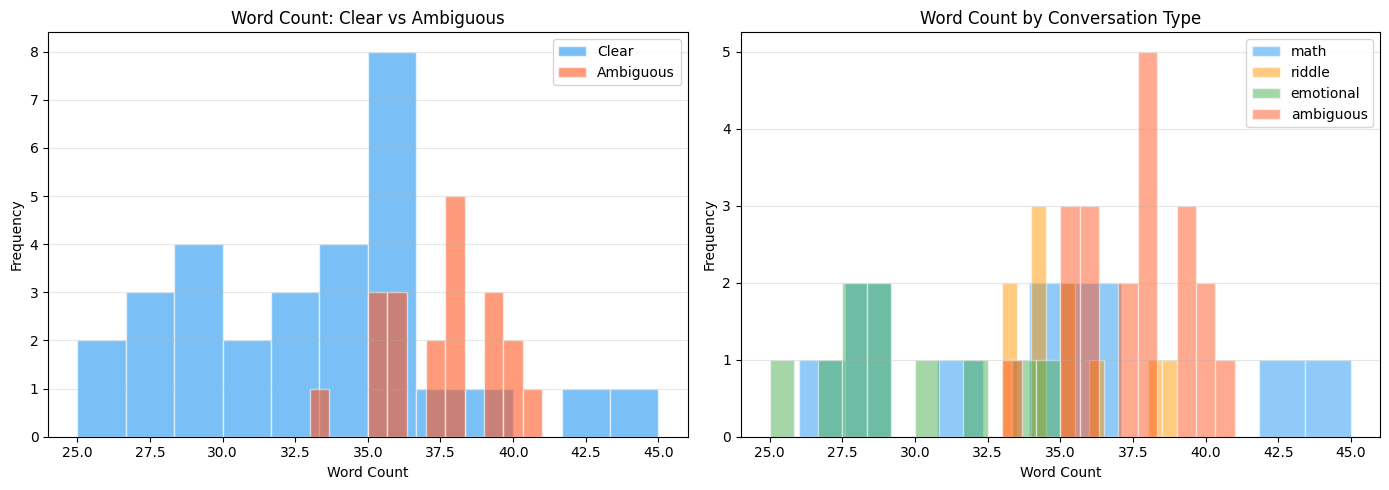


Test dataset creation complete!


In [14]:
# Cell 7: Summary Statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print("\nCounts by conversation_type:")
print(df_all["conversation_type"].value_counts())

print("\nCounts by blend_type:")
print(df_all["blend_type"].value_counts())

print("\nWord count stats â€” Clear vs Ambiguous:")
print(df_all.groupby("ambiguous")["word_count"].agg(["mean", "std", "min", "max"]).round(2))

print("\nWord count stats â€” By conversation_type:")
print(df_all.groupby("conversation_type")["word_count"].agg(["mean", "std", "min", "max"]).round(2))

# Plot word count distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: clear vs ambiguous
for label, color in [(False, "#2196F3"), (True, "#FF5722")]:
    subset = df_all[df_all["ambiguous"] == label]["word_count"]
    tag = "Ambiguous" if label else "Clear"
    axes[0].hist(subset, bins=12, alpha=0.6, label=tag, color=color, edgecolor="white")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Word Count: Clear vs Ambiguous")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Right: by conversation type
colors = {"math": "#2196F3", "riddle": "#FF9800", "emotional": "#4CAF50", "ambiguous": "#FF5722"}
for cat in ["math", "riddle", "emotional", "ambiguous"]:
    subset = df_all[df_all["conversation_type"] == cat]["word_count"]
    axes[1].hist(subset, bins=12, alpha=0.5, label=cat, color=colors[cat], edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Word Count by Conversation Type")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("test_word_count_distribution.png", dpi=150)
plt.show()

print("\nTest dataset creation complete!")